In [7]:
using MyPackage
using MyPackage.Geometry
using MyPackage.VLM

using Printf

function new_plane()
    plain = Airfoil("../assets/airfoils/Plain/Plain.dat")
    wing = Aerosurface(
        airfoils=[plain, plain],
        b=6.0,
        chord=y -> 2 * (1 - y^2)^0.5,
        sw_center=0.5,
        mirror_xz=false
    )
    wing2 = Aerosurface(
        airfoils=[plain, plain],
        b=6.0,
        chord=y -> 2 * (1 - (1-y)^2)^0.5,
        sw_center=0.5,
        mirror_xz=false,
        pos=(1.0, -3.0, 0.0)
    )
    return Plane([wing, wing2])
end

function new_plane2()
    s1223 = Airfoil("../assets/airfoils/S1223/S1223.dat")
    wing = Aerosurface(
        airfoils=[s1223, s1223],
        b=0.850,
        chord=y -> 0.2,
        sw_center=0.5,
        pos=(0.6, 0.0, 0.0)
    )
    hstab = Aerosurface(
        airfoils=[s1223, s1223],
        b=0.34,
        chord=y -> 0.1,

    )
    return Plane([wing, hstab])
end

function run_example()
    println("\n" * "="^72)
    println("VLM Solver Example")
    println("="^72)

    V_mag = 10.0
    alpha_deg = 5.0
    beta_deg = 0.0
    rho = 1.225
    mu = 1.81 * 10^(-5)
    # S_ref = 0.85*0.2
    S_ref = 3 * pi
    q_inf = 0.5 * rho * V_mag^2

    plane = new_plane()

    println("\nFreestream: V = $(V_mag) m/s, alpha = $(alpha_deg)°, beta = $(beta_deg)°")
    println("Reference area: $(S_ref) m²")
    println("Q inf: $(q_inf)")
    println("CG: $(plane.data.CG)")

    t0 = time()
    FX, FX_dist, FY, FY_dist, FZ, FZ_dist, L, L_dist, D, D_dist, M, M_dist, Ml, Ml_dist, N, N_dist, L_trefftz, L_dist_trefftz, D_trefftz, D_dist_trefftz = VLMSolver(
        plane,
        V_mag,
        (alpha_deg, beta_deg);
        n_chordxspan=[(20, 30), (20, 30)],
        rho=rho,
        epsilon2=10^(-10)
    )
    elapsed = time() - t0

    CL = sum(L) / (q_inf * S_ref)
    CD = sum(D) / (q_inf * S_ref)
    CL_trefftz = sum(L_trefftz) / (q_inf * S_ref)
    CD_trefftz = sum(D_trefftz) / (q_inf * S_ref)

    Re = rho * V_mag * plane.surfaces[1].MAC / mu

    println("\nResults")
    println("-"^72)
    @printf("Solve time       : %.3f s\n", elapsed)
    @printf("Reynolds number  : %.1f\n", Re)
    @printf("FX               : %.6f N\n", FX[1])
    @printf("FY               : %.6f N\n", FY[1])
    @printf("FZ               : %.6f N\n", FZ[1])
    @printf("Lift             : %.6f N\n", L[1])
    @printf("Drag             : %.6f N\n", D[1])
    @printf("CL               : %.6f\n", CL)
    @printf("CD               : %.6f\n", CD)
    @printf("Trefftz lift     : %.6f N\n", L_trefftz[1])
    @printf("Trefftz drag     : %.6f N\n", D_trefftz[1])
    @printf("Trefftz CL       : %.6f N\n", CL_trefftz)
    @printf("Trefftz CD       : %.6f N\n", CD_trefftz)

    return FX, FX_dist, FY, FY_dist, FZ, FZ_dist, L, L_dist, D, D_dist, M, M_dist, Ml, Ml_dist, N, N_dist, L_trefftz, L_dist_trefftz, D_trefftz, D_dist_trefftz
end

FX, FX_dist, FY, FY_dist, FZ, FZ_dist, L, L_dist, D, D_dist, M, M_dist, Ml, Ml_dist, N, N_dist, L_trefftz, L_dist_trefftz, D_trefftz, D_dist_trefftz = run_example()


VLM Solver Example
Loading airfoil: Plain from ../assets/airfoils/Plain/Plain.dat

Freestream: V = 10.0 m/s, alpha = 5.0°, beta = 0.0°
Reference area: 9.42477796076938 m²
Q inf: 61.25000000000001
CG: (0.4187010201065039, 0.0, 0.0)

Results
------------------------------------------------------------------------
Solve time       : 2.063 s
Reynolds number  : 1133500.0
FX               : 0.000000 N
FY               : -0.000000 N
FZ               : 93.335327 N
Lift             : 92.980158 N
Drag             : 8.134710 N
CL               : 0.322029
CD               : 0.028174
Trefftz lift     : 93.497498 N
Trefftz drag     : 2.468293 N
Trefftz CL       : 0.323931 N
Trefftz CD       : 0.008552 N


([6.972483272120349e-16, 2.91632990324167e-16], [[6.331700013672516e-16, -2.777028475328752e-16, 4.569470206995166e-16, -4.629600901387833e-16, -1.631374749904196e-16, -8.612648967675381e-16, -7.75703752726502e-17, -4.715913731074614e-16, 3.998002726846751e-16, 2.9648085382737156e-16  …  -3.99313654655178e-16, 2.830808185843412e-17, 3.49228176238066e-17, -1.6271604205604164e-16, 3.913310581460132e-17, 5.558084714806948e-17, -2.860921947173944e-17, 5.1769222561927904e-17, 9.046196800829638e-18, -4.881318903667083e-17], [-7.623092277592151e-18, -1.3950251541175285e-17, 1.8922941225156818e-17, -9.936280995049057e-18, 2.0424205841111416e-18, 6.001357638388423e-17, -1.0313367238598116e-17, -7.60528639198014e-17, 5.217320279325534e-16, -3.4356449781472714e-16  …  -4.2261331066414246e-16, 1.8345536612382184e-16, 4.263881414975606e-16, -2.648283350877146e-16, 3.42512601771863e-17, -6.667308361612428e-16, 5.319180206046984e-16, 2.593827315097799e-16, 3.4877349730927134e-16, -1.4069444506036205e

In [ ]:
using Plots

plot(rand(10))

In [ ]:
using Plots

n_span = 60
y1 = (1 .- cos.(range(0; stop=pi, length=n_span + 1))) .* 3 ./ 2
y = Vector{Float64}(undef, 2*n_span)

for i in 1:n_span
    y[n_span - i + 1] = - (y1[i+1] + y1[i]) / 2
    y[n_span + i] = (y1[i+1] + y1[i]) / 2
end

Plots.plot(y, L_dist_trefftz[1])

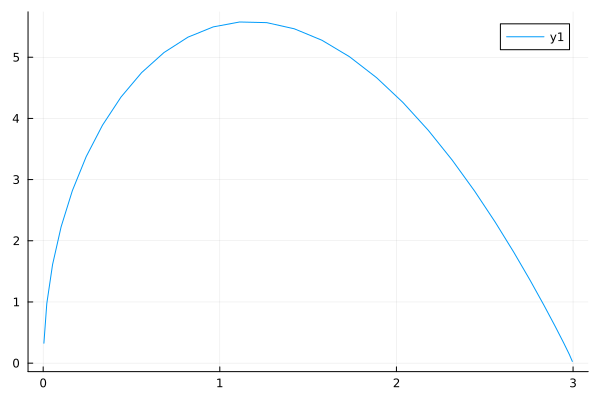

In [8]:
using Plots

n_span = 30
y1 = (1 .- cos.(range(0; stop=pi, length=n_span + 1))) .* 3 ./ 2
y = Vector{Float64}(undef, n_span)

for i in 1:n_span
    y[i] = (y1[i+1] + y1[i]) / 2
end

Plots.plot(y, L_dist_trefftz[1])